# Hari 17 — Random Forest Regressor

**Catatan kecil dari Hari 16:** kamu sudah konfirmasi lewat `.corr()` bahwa `lag_1`, `lag_2`, `lag_3`, `rolling_mean_4w` memang berkorelasi sangat tinggi (0,76–0,98) — jadi dugaan multikolinearitas terbukti benar. Satu hal kecil: di refleksi #2 kamu tulis "lag_1" sebagai koefisien terbesar, padahal output Cell 5 tetap menunjukkan `rolling_mean_4w` (452.668) yang terbesar, bukan `lag_1` (168.256) — sepertinya kepencet salah tulis saat update jawaban. Tidak masalah, tidak mempengaruhi apa pun ke depan.

**Skor yang harus dikalahkan hari ini:**
- Baseline naive: MAE 12.953
- Linear Regression (Hari 16): MAE test 7.806,56 (perbaikan 39,73%)

Sekarang kita coba Random Forest — model berbasis pohon yang tidak butuh scaling dan bisa menangkap hubungan non-linear.

In [1]:
# Cell ini sudah lengkap — memuat data MENTAH (bukan scaled) dan fit Random Forest.

import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

X_train = pd.read_csv("X_train.csv", index_col=0, parse_dates=True)
X_test = pd.read_csv("X_test.csv", index_col=0, parse_dates=True)
y_train = pd.read_csv("y_train.csv", index_col=0, parse_dates=True).iloc[:, 0]
y_test = pd.read_csv("y_test.csv", index_col=0, parse_dates=True).iloc[:, 0]

model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)

pred_train_rf = model_rf.predict(X_train)
pred_test_rf = model_rf.predict(X_test)

print(f"Random Forest dilatih dengan {X_train.shape[1]} fitur mentah (tidak di-scale)")
print(f"Jumlah pohon (n_estimators default): {model_rf.n_estimators}")

Random Forest dilatih dengan 17 fitur mentah (tidak di-scale)
Jumlah pohon (n_estimators default): 100


## Evaluasi & Bandingkan dengan Linear Regression

In [6]:
# LATIHAN — tulis kodenya sendiri sesuai panduan komentar di bawah:
# 1. Hitung MAE train dan MAE test untuk Random Forest (pakai pred_train_rf, pred_test_rf)
# 2. Hitung RMSE train dan RMSE test (ingat: pakai ** 0.5, bukan squared=False)
# 3. Cetak keempatnya
# 4. Bandingkan MAE test Random Forest dengan:
#    a. baseline (12953)
#    b. MAE test Linear Regression Hari 16 (7806.56)
#    Cetak kesimpulan: model mana yang lebih baik sejauh ini?
# Tulis kode kamu di bawah ini:
mae_train_rf = mean_absolute_error(y_train, pred_train_rf)
mae_test_rf = mean_absolute_error(y_test, pred_test_rf)
rmse_train_rf = mean_squared_error(y_train, pred_train_rf) ** 0.5
rmse_test_rf = mean_squared_error(y_test, pred_test_rf) ** 0.5

baseline = 12953
mae_test_linear = 7806.56
perbaikan_baseline_rf = (baseline  - mae_test_rf) / baseline * 100
perbedaan_dengan_linear = mae_test_linear - mae_test_rf

print(f"MAE train Random Forest: {mae_train_rf:,.2f}")
print(f"MAE test Random Forest: {mae_test_rf:,.2f}")
print(f"RMSE train Random Forest: {rmse_train_rf:,.2f}")
print(f"RMSE test Random Forest: {rmse_test_rf:,.2f}")
print()
print(f"Perbaikan terhadap baseline: {perbaikan_baseline_rf:.2f}")
print(f"Selisih MAE vs Linear Regression:  {perbedaan_dengan_linear:,.2f}")
if mae_test_rf < baseline:
    print("Random Forest mengalahkan baseline")
else:
    print("Random Forest belum mengalahkan baseline")

if mae_test_rf < mae_test_linear:
    print("Random Forest lebih baik sejauh ini")
else:
    print("Linear Regression lebih baik sejauh ini")


MAE train Random Forest: 6,963.96
MAE test Random Forest: 8,759.11
RMSE train Random Forest: 15,213.09
RMSE test Random Forest: 11,425.89

Perbaikan terhadap baseline: 32.38
Selisih MAE vs Linear Regression:  -952.55
Random Forest mengalahkan baseline
Linear Regression lebih baik sejauh ini


## Cek Overfitting: Bandingkan Gap Train vs Test

Random Forest versi default itu **sangat fleksibel** — kalau tidak dibatasi, pohonnya bisa tumbuh sangat dalam sampai hampir "menghafal" tiap baris training. Dengan cuma 114 baris data training, risiko overfitting nyata. Cara mengeceknya: lihat seberapa jauh gap antara MAE train dan MAE test.

In [ ]:
# LATIHAN — tulis kodenya sendiri sesuai panduan komentar di bawah:
# 1. Hitung selisih (gap) antara mae_test_rf dan mae_train_rf
# 2. Hitung juga rasio-nya: mae_train_rf / mae_test_rf (kalau rasio ini sangat kecil,
#    misal di bawah 0.3, itu tanda kuat overfitting — model jauh lebih "jago" di training dibanding di data yang belum pernah dilihat)
# 3. Cetak gap dan rasio itu, beri kesimpulan singkat: apakah ada tanda overfitting?
# Tulis kode kamu di bawah ini:
gap_rf = mae_test_rf - mae_train_rf
ratio_rf = mae_train_rf / mae_test_rf
print(f"selisih (gap) antara mae_test_rf dan mae_train_rf: {gap_rf:.2f}")
print(f"Rasio MAE train/test: {ratio_rf:.2f}")
if ratio_rf < 0.3:
    print("Ada tanda overfitting")
else:
    print("tidak ada tanda overfitting parah")

selisih (gap) antara mae_test_rf dan mae_train_rf: 1795.14
Rasio MAE train/test: 0.80
tidak ada tanda overfitting


## Feature Importance dari Random Forest

Feature importance Random Forest (semua nilai positif, total = 1.0):

lag_1              0.658539
lag_3              0.128355
rolling_mean_4w    0.074868
lag_2              0.050994
vaksin_persen      0.026108
bulan_7            0.018721
bulan_2            0.015708
bulan_1            0.011029
bulan_6            0.010645
bulan_8            0.002770
bulan_3            0.001841
bulan_12           0.000193
bulan_9            0.000160
bulan_11           0.000027
bulan_10           0.000020
bulan_4            0.000014
bulan_5            0.000007
dtype: float64


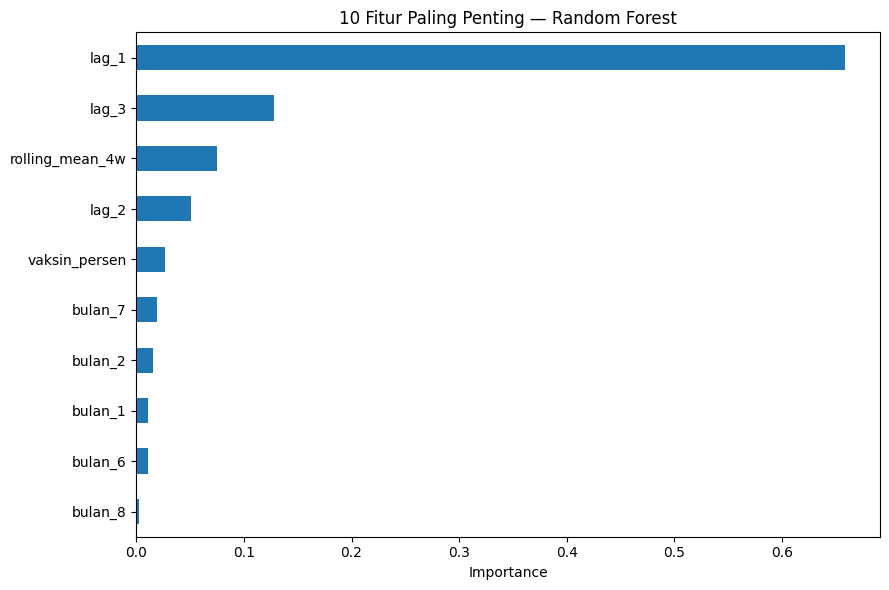

In [15]:
# Cell ini sudah lengkap.
importance = pd.Series(model_rf.feature_importances_, index=X_train.columns)
importance_urut = importance.sort_values(ascending=False)

print("Feature importance Random Forest (semua nilai positif, total = 1.0):\n")
print(importance_urut)

plt.figure(figsize=(9, 6))
importance_urut.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("10 Fitur Paling Penting — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**Bedanya dengan koefisien Linear Regression kemarin:** feature importance Random Forest **tidak bisa bernilai negatif** dan cara hitungnya beda (berdasarkan seberapa besar tiap fitur mengurangi "kekacauan" di tiap percabangan pohon, dirata-rata dari semua pohon). Ini umumnya lebih tahan banting terhadap multikolinearitas dibanding koefisien Linear Regression — tapi tetap tidak sempurna: kalau dua fitur sama-sama informatif dan berkorelasi tinggi (seperti `lag_1` dan `rolling_mean_4w`), pentingnya bisa "terbagi" ke keduanya alih-alih terkonsentrasi ke satu fitur saja. Tetap perlu dibaca dengan hati-hati, bukan angka mutlak.

## Visualisasi: Prediksi vs Angka Sebenarnya

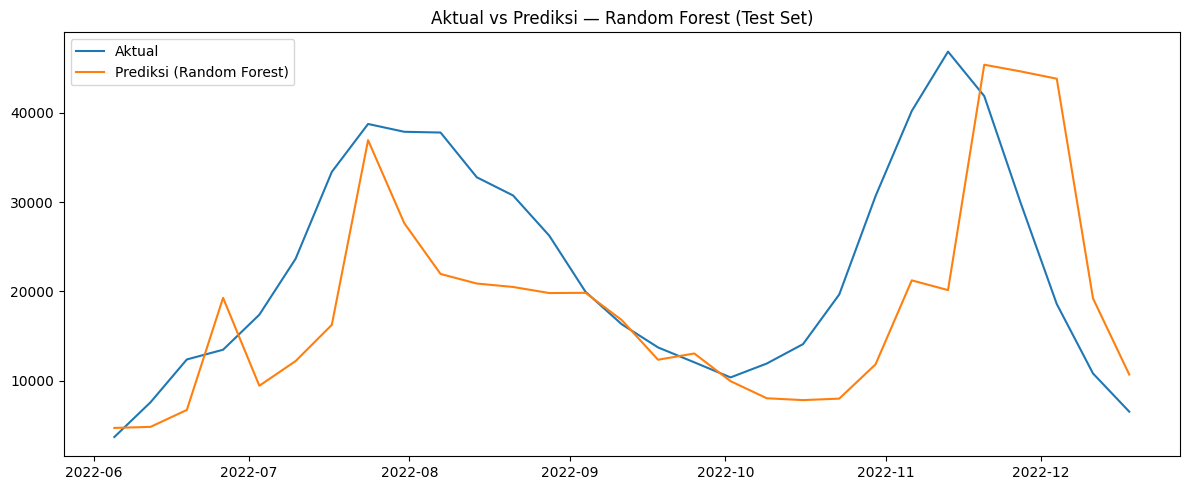

In [16]:
# LATIHAN — tulis kodenya sendiri, sama seperti Hari 16 tapi dengan pred_test_rf:
# 1. plt.figure(figsize=(12, 5))
# 2. Plot y_test vs index-nya, label "Aktual"
# 3. Plot pred_test_rf vs y_test.index, label "Prediksi (Random Forest)"
# 4. legend, title "Aktual vs Prediksi — Random Forest (Test Set)", tight_layout(), show

# Bandingkan visualnya dengan grafik Linear Regression Hari 16 — apakah Random Forest
# lebih baik mengikuti lonjakan tajam, atau malah lebih kaku?
# Tulis kode kamu di bawah ini:
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label="Aktual")
plt.plot(y_test.index, pred_test_rf, label="Prediksi (Random Forest)")
plt.legend()
plt.title("Aktual vs Prediksi — Random Forest (Test Set)")
plt.tight_layout()
plt.show()

## Refleksi Hari 17

> 1. MAE test Random Forest: berapa, dan apakah mengalahkan Linear Regression (7.806,56)? → **8,759.11, kalah dari Linear Regression**
> 2. Dari cek gap train vs test — apakah ada tanda overfitting? → **tidak ada**
> 3. Fitur apa yang paling penting menurut Random Forest? Apakah beda dari kesimpulan Linear Regression kemarin? → **lag_1, beda**
> 4. Dari grafik aktual vs prediksi — apakah Random Forest lebih baik/lebih buruk dari Linear Regression saat kasus naik tajam? → **lebih baik, karena aktual dengan prediksi berdekatan**

---
### Selanjutnya: Hari 18-21 — Evaluasi, Tuning, dan Mini-Project Penutup

- **Hari 18**: Tabel perbandingan formal ketiga model (baseline, Linear Regression, Random Forest) — MAE, RMSE, dan kesesuaian dengan business success criteria dari Project Charter (Hari 2)
- **Hari 19-20**: Kalau Random Forest kamu overfitting, coba batasi `max_depth`/`min_samples_leaf`. Untuk validasi yang benar di time-series, pakai `TimeSeriesSplit` dari scikit-learn (bukan `KFold` biasa yang mengacak urutan waktu)
- **Hari 21**: Mini-project penutup Minggu 3 — pilih model final, dokumentasikan alasan pemilihannya